In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
data = pd.read_csv("WA_FnUseC_TelcoCustomerChurn.csv")

# Convert TotalCharges to numeric
data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce"
)

# Fill missing values
data["TotalCharges"] = data["TotalCharges"].fillna(
    data["TotalCharges"].median()
)

# Convert target variable
data["Churn"] = data["Churn"].map({
    "Yes": 1,
    "No": 0
})

# Remove customer ID
data = data.drop(columns=["customerID"])

# Separate features and target
y = data["Churn"]
X = data.drop(columns=["Churn"])

# One-hot encode categorical features
X = pd.get_dummies(
    X,
    columns=X.select_dtypes(include=["object"]).columns,
    drop_first=True,
    dtype=int
)

print("Dataset prepared successfully!")
print("Features:", X.shape)
print("Target:", y.shape)

Dataset prepared successfully!
Features: (7043, 30)
Target: (7043,)


C:\Users\aatik\AppData\Local\Temp\ipykernel_23088\3642516232.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columns=X.select_dtypes(include=["object"]).columns,


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train-test split completed!")
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Train-test split completed!
Training data: (5634, 30)
Testing data: (1409, 30)


In [4]:
baseline_rf = RandomForestClassifier(
    random_state=42
)

baseline_rf.fit(X_train, y_train)

baseline_predictions = baseline_rf.predict(X_test)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print("Untuned Random Forest Accuracy:", baseline_accuracy)

Untuned Random Forest Accuracy: 0.7863733144073811


In [5]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

print("Hyperparameter grid created!")
print(param_grid)

Hyperparameter grid created!
{'n_estimators': [100, 200], 'max_depth': [None, 5, 10], 'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2]}


In [6]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("Starting GridSearchCV...")
grid_search.fit(X_train, y_train)

print("GridSearchCV completed!")

Starting GridSearchCV...
GridSearchCV completed!


In [7]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}

Best Cross-Validation Accuracy:
0.8008496440509945


In [8]:
tuned_rf = grid_search.best_estimator_

tuned_predictions = tuned_rf.predict(X_test)

tuned_accuracy = accuracy_score(
    y_test,
    tuned_predictions
)

print("Untuned Random Forest Accuracy:", baseline_accuracy)
print("Tuned Random Forest Accuracy:", tuned_accuracy)

Untuned Random Forest Accuracy: 0.7863733144073811
Tuned Random Forest Accuracy: 0.8034066713981547


In [9]:
performance_comparison = pd.DataFrame({
    "Model": [
        "Random Forest - Untuned",
        "Random Forest - Tuned"
    ],
    "Accuracy": [
        baseline_accuracy,
        tuned_accuracy
    ]
})

print("Performance Comparison:")
print(performance_comparison)

Performance Comparison:
                     Model  Accuracy
0  Random Forest - Untuned  0.786373
1    Random Forest - Tuned  0.803407


In [10]:
improvement = tuned_accuracy - baseline_accuracy

print("Accuracy Improvement:", improvement)
print(
    "Improvement (%):",
    round(improvement * 100, 2),
    "%"
)

Accuracy Improvement: 0.017033356990773574
Improvement (%): 1.7 %


In [11]:
print("HYPERPARAMETER OPTIMIZATION ANALYSIS")
print("-" * 45)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nUntuned Accuracy:", round(baseline_accuracy, 4))
print("Tuned Accuracy:", round(tuned_accuracy, 4))

if tuned_accuracy > baseline_accuracy:
    print("\nTuning improved test-set accuracy.")
elif tuned_accuracy < baseline_accuracy:
    print("\nTuning reduced test-set accuracy.")
else:
    print("\nTuning produced the same test-set accuracy.")

print("\nTrade-off:")
print("Hyperparameter tuning requires additional computation")
print("because multiple parameter combinations are evaluated.")

HYPERPARAMETER OPTIMIZATION ANALYSIS
---------------------------------------------
Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}

Untuned Accuracy: 0.7864
Tuned Accuracy: 0.8034

Tuning improved test-set accuracy.

Trade-off:
Hyperparameter tuning requires additional computation
because multiple parameter combinations are evaluated.


In [12]:
best_parameter_report = pd.DataFrame({
    "Parameter": list(grid_search.best_params_.keys()),
    "Best Value": list(grid_search.best_params_.values())
})

print("Best Parameter Report:")
print(best_parameter_report)

best_parameter_report.to_csv(
    "best_parameters_report.csv",
    index=False
)

print("\nBest parameter report saved successfully!")

Best Parameter Report:
           Parameter  Best Value
0          max_depth          10
1   min_samples_leaf           2
2  min_samples_split           5
3       n_estimators         100

Best parameter report saved successfully!


In [13]:
performance_comparison.to_csv(
    "hyperparameter_performance_comparison.csv",
    index=False
)

print("Performance comparison saved successfully!")

Performance comparison saved successfully!


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

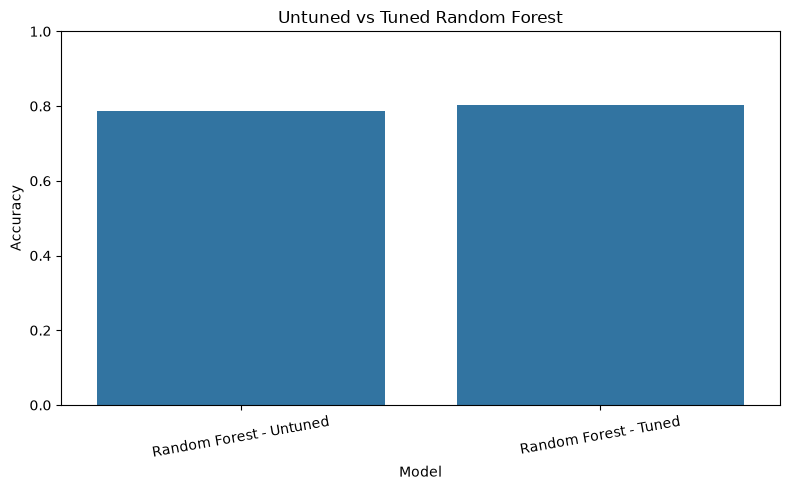

Performance visualization saved successfully!


In [17]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=performance_comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Untuned vs Tuned Random Forest")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig("hyperparameter_tuning_comparison.png", dpi=300)
plt.show()

print("Performance visualization saved successfully!")

In [18]:
print("DAY 26 - HYPERPARAMETER TUNING ANALYSIS")
print("-" * 50)

print("Untuned Random Forest Accuracy:",
      round(baseline_accuracy, 4))

print("Tuned Random Forest Accuracy:",
      round(tuned_accuracy, 4))

print("\nBest Parameters:")
for parameter, value in grid_search.best_params_.items():
    print(f"{parameter}: {value}")

print("\nOptimization Trade-offs:")
print("- GridSearchCV evaluates multiple parameter combinations.")
print("- More combinations require more computation time.")
print("- Cross-validation makes the parameter selection more reliable.")
print("- The tuned model should be evaluated on unseen test data.")

DAY 26 - HYPERPARAMETER TUNING ANALYSIS
--------------------------------------------------
Untuned Random Forest Accuracy: 0.7864
Tuned Random Forest Accuracy: 0.8034

Best Parameters:
max_depth: 10
min_samples_leaf: 2
min_samples_split: 5
n_estimators: 100

Optimization Trade-offs:
- GridSearchCV evaluates multiple parameter combinations.
- More combinations require more computation time.
- Cross-validation makes the parameter selection more reliable.
- The tuned model should be evaluated on unseen test data.
